# ICU Mortality Prediction using Machine Learning

This notebook demonstrates
- Data preprocessing using MIMIC-IV dataset
- Feature engineering
- Model training (Logistic Regression, SMOTE, Random Forest)
- Evaluation using F1-score and AUROC

## Importing Required Modules

In [7]:
from modules.data_processor import PatientDataProcessor
from modules.model import MortalityPredictor
from modules.utils import plot_mortality_distribution, plot_model_f1_scores

## Data Loading and Preprocessing

In [8]:
processor = PatientDataProcessor("data")

processor.load_data()
processor.merge_data()
processor.clean_data()
processor.feature_engineering()

print(processor)

df = processor.get_model_data()

print("\nMortality Distribution:")
print(df["mortality"].value_counts())

df.head()

Dataset with 73181 records

Mortality Distribution:
mortality
0    64852
1     8329
Name: count, dtype: int64


,anchor_age,gender_encoded,los,mortality
0,52,0,0.410266,0
1,73,0,0.497535,0
2,55,0,1.118032,0
3,55,0,0.948113,0
4,46,0,1.338588,0


## Mortality Distribution Visualization

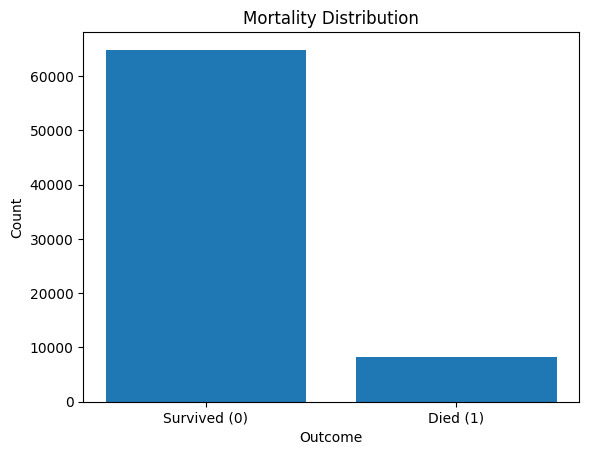

In [9]:
plot_mortality_distribution(df)

## Model Initialization

In [10]:
predictor = MortalityPredictor(df)
predictor.split_data()

print(predictor)

MortalityPredictor with 73181 samples


## Logistic Regression (Baseline Model)

In [12]:
predictor.train_logistic_regression()
lr_results = predictor.evaluate_model("logistic_regression")

print("Logistic Regression Results")
print("Accuracy:", lr_results["accuracy"])
print("F1 Score:", lr_results["f1_score"])
print("AUROC:", lr_results["auroc"])
print("Confusion Matrix:\n", lr_results["confusion_matrix"])
print(lr_results["classification_report"])

Logistic Regression Results
Accuracy: 0.8852907016465122
F1 Score: 0.01060695344725987
AUROC: 0.6425055644029256
Confusion Matrix:
 [[12949    22]
 [ 1657     9]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     12971
           1       0.29      0.01      0.01      1666

    accuracy                           0.89     14637
   macro avg       0.59      0.50      0.47     14637
weighted avg       0.82      0.89      0.83     14637



## Logistic Regression with SMOTE

In [13]:
predictor.train_logistic_regression_smote()
smote_results = predictor.evaluate_model("logistic_regression_smote")

print("Logistic Regression + SMOTE Results")
print("Accuracy:", smote_results["accuracy"])
print("F1 Score:", smote_results["f1_score"])
print("AUROC:", smote_results["auroc"])
print("Confusion Matrix:\n", smote_results["confusion_matrix"])
print(smote_results["classification_report"])

Logistic Regression + SMOTE Results
Accuracy: 0.6064767370362779
F1 Score: 0.2619169656586366
AUROC: 0.6443318750675044
Confusion Matrix:
 [[7855 5116]
 [ 644 1022]]
              precision    recall  f1-score   support

           0       0.92      0.61      0.73     12971
           1       0.17      0.61      0.26      1666

    accuracy                           0.61     14637
   macro avg       0.55      0.61      0.50     14637
weighted avg       0.84      0.61      0.68     14637



## Random Forest Model

In [14]:
predictor.train_random_forest()
rf_results = predictor.evaluate_model("random_forest")

print("Random Forest Results")
print("Accuracy:", rf_results["accuracy"])
print("F1 Score:", rf_results["f1_score"])
print("AUROC:", rf_results["auroc"])
print("Confusion Matrix:\n", rf_results["confusion_matrix"])
print(rf_results["classification_report"])

Random Forest Results
Accuracy: 0.8194302111088337
F1 Score: 0.146593477558928
AUROC: 0.5901858546209324
Confusion Matrix:
 [[11767  1204]
 [ 1439   227]]
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     12971
           1       0.16      0.14      0.15      1666

    accuracy                           0.82     14637
   macro avg       0.52      0.52      0.52     14637
weighted avg       0.81      0.82      0.81     14637



## Model Comparison

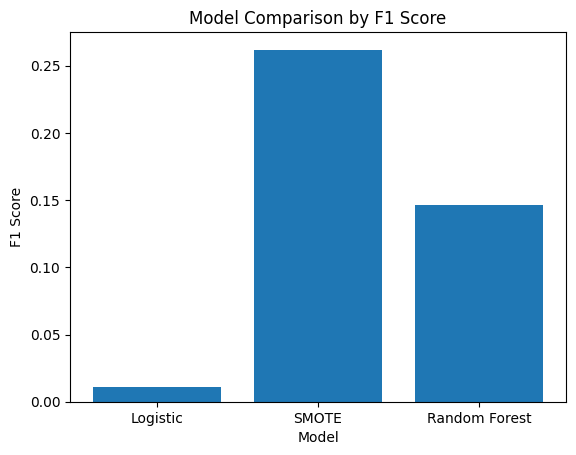

In [15]:
f1_scores = {
    "Logistic": lr_results["f1_score"],
    "SMOTE": smote_results["f1_score"],
    "Random Forest": rf_results["f1_score"]
}

plot_model_f1_scores(f1_scores)

## Additional Features (Advanced Python Requirements)

In [16]:
print("\nUnique ICU Units:")
print(processor.get_unique_units())

print("\nRandom Sample:")
print(processor.get_random_sample(5))

print("\nGenerator Output (first 3 rows):")
gen = processor.row_generator()
for _ in range(3):
    print(next(gen))


Unique ICU Units:
['Cardiac Vascular Intensive Care Unit (CVICU)', 'Coronary Care Unit (CCU)', 'Medical Intensive Care Unit (MICU)', 'Medical/Surgical Intensive Care Unit (MICU/SICU)', 'Neuro Intermediate', 'Neuro Stepdown', 'Neuro Surgical Intensive Care Unit (Neuro SICU)', 'Surgical Intensive Care Unit (SICU)', 'Trauma SICU (TSICU)']

Random Sample:
       subject_id gender  anchor_age  anchor_year anchor_year_group  \
21118    12884677      M          52         2162       2008 - 2010   
157      10020740      M          56         2150       2014 - 2016   
62271    18508697      M          34         2158       2008 - 2010   
7830     11083655      M          75         2180       2008 - 2010   
58956    18064941      M          61         2130       2017 - 2019   

             dod   hadm_id           admittime           dischtime  \
21118        NaT  20238366 2162-12-22 14:16:00 2162-12-27 15:00:00   
157          NaT  23831430 2150-03-11 15:34:00 2150-04-25 13:50:00   
62271   